In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Append the src directory to system path to enable modular imports
# Adjust this path if your notebook is in a different relative subdirectory
sys.path.append(os.path.abspath('../src/'))

# Import your production engines directly
from build_dataset import execute_full_pipeline
from train_model import train_production_engine, characterize_stock_regime

# Graphics configuration for clear financial charts
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [3]:
import os

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Created 'data' directory.")
else:
    print("'data' directory already exists.")

Created 'data' directory.


In [4]:
# --- CONFIGURATION ASSIGNMENT MAP ---
TARGET_ASSET = "NVDA"
SECTOR_BENCHMARK = "SOXX"
START_DATE = "2022-01-01"
END_DATE = "2026-06-22"

print("🚀 Step 1: Triggering Production Data Pipeline Module...")
execute_full_pipeline(
    ticker=TARGET_ASSET, 
    sector_ticker=SECTOR_BENCHMARK, 
    start=START_DATE, 
    end=END_DATE
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

🚀 Step 1: Triggering Production Data Pipeline Module...
=== STARTING MASTER QUANT DATA PIPELINE FOR NVDA ===
Initializing data download for NVDA from 2022-01-01 to 2026-06-22...
Fetching data for NVDA (asset)...
Fetching data for ^GSPC (spy)...
Fetching data for ^VIX (vix)...
Data fetch complete. Total rows captured: 1119
Extracting structural corporate financials for NVDA...
Success: Real dynamic fundamental traits extracted successfully!
Verify Fundamental Output Rows: 1119
Beginning mathematical feature engineering extraction...
Feature engineering complete. Total feature columns generated: 27
Executing Strategy A: Dynamic Pre-Earnings Target Labeling...
⚠️ Insufficient quarterly steps detected (4 found, expected ~16).
   Likely missing/annual data fields. Deploying synthetic 63-day fiscal cycle barriers...
Cleanly extracted 17 historical earnings dates from stationary EPS states.


Target distribution :
target
 0    465
 1    357
-1    232
Name: count, dtype: int64
🔄 Normalizing raw valuation metrics via 1-Year Rolling Z-Scores...
📥 Fetching Sector Benchmark ETF Data (SOXX)...
📐 Calculating asset-to-sector relative momentum indicators...
✅ Sector spread engineering complete and cleaned.

=== PIPELINE DATA CONSOLIDATION COMPLETE ===
Total clean sample matrix rows: 1054
Total features matrix columns: 38

Successfully segmented matrices chronologically:
├── Training Set Span: 2022-04-06 to 2025-08-15 (843 rows)
└── Testing Set Span:  2025-08-18 to 2026-06-18 (211 rows)

Matrices exported successfully to data/ folder. Ready for model training.


In [5]:
print("🔒 Step 2: Running Ticker-Agnostic Model Training Harness...")

# Train model and grab the final fitted sklearn Pipeline object
fitted_pipeline = train_production_engine(
    identifier=TARGET_ASSET,
    train_path="data/train_matrix.csv",
    test_path="data/test_matrix.csv"
)

🔒 Step 2: Running Ticker-Agnostic Model Training Harness...

🔒 EXECUTING TICKER-AGNOSTIC PRODUCTION HARNESS v5.5: [NVDA]

🔍 RUNNING ALGORITHMIC REGIME CHARACTERIZATION...
-> 5-Day Velocity Autocorrelation: 0.0433
-> Average Historical Baseline Volatility: 0.0326
-> True Historical Valuation Baseline (Median P/E): 63.24
🎯 REGIME DIAGNOSIS: TYPE-A [High-Reflexivity Breakout Engine]

=== PERFORMANCE SUMMARY (NVDA | TYPE_A_MOMENTUM) ===
              precision    recall  f1-score   support

    Skip (0)       0.91      0.89      0.90       184
     Buy (1)       0.34      0.41      0.37        27

    accuracy                           0.82       211
   macro avg       0.63      0.65      0.64       211
weighted avg       0.84      0.82      0.83       211



In [7]:
# Load the datasets back into memory for evaluation
train_df = pd.read_csv("data/train_matrix.csv", index_col="Date", parse_dates=True)
test_df = pd.read_csv("data/test_matrix.csv", index_col="Date", parse_dates=True)

# Re-diagnose the regime locally so our notebook knows which features were chosen
regime = characterize_stock_regime(train_df)

# Re-map selected features to match train_model.py exactly
if regime in ["TYPE_A_MOMENTUM", "TYPE_C_REFLEXIVE_VALUE"]:
    features = ['ratio_pe', 'feature_trend_20d_velocity', 'feature_ratio_pe_velocity_5d', 'trend_60d_sector_spread', 'volatility_20d']
else: # TYPE_B
    features = ['ratio_pe', 'feature_trend_20d_velocity', 'feature_ratio_pe_velocity_5d']

# Isolate testing variables
X_test = test_df[features].copy()
y_test = test_df['target'].apply(lambda x: 1 if x == 1 else 0)

# Inject the distance metric if applicable to the diagnosed regime
if regime in ["TYPE_B_MEAN_REVERSION", "TYPE_C_REFLEXIVE_VALUE"]:
    X_test['feature_pe_distance_from_median'] = test_df['ratio_pe'] - train_df['ratio_pe'].median()

# Inject the momentum acceleration feature
X_test['feature_momentum_acceleration'] = np.where(
    (X_test['feature_trend_20d_velocity'] > 0) & (X_test['feature_ratio_pe_velocity_5d'] > 0),
    X_test['feature_trend_20d_velocity'] * X_test['feature_ratio_pe_velocity_5d'], 0.0
)

# Generate predictions using your dynamic percentile allocation logic
y_prob = fitted_pipeline[0].predict_proba(X_test)[:, 1]

# Dynamic threshold boundaries mapping back to your model configurations
threshold_map = {"TYPE_A_MOMENTUM": 85.0, "TYPE_B_MEAN_REVERSION": 80.0, "TYPE_C_REFLEXIVE_VALUE": 83.0}
target_percentile = threshold_map[regime]
dynamic_threshold = np.percentile(y_prob, target_percentile)
y_pred = (y_prob >= dynamic_threshold).astype(int)

print(f"\n📊 Diagnostics Complete. Generated prediction array based on {target_percentile}th percentile cutoff threshold ({dynamic_threshold:.4f}).")


🔍 RUNNING ALGORITHMIC REGIME CHARACTERIZATION...
-> 5-Day Velocity Autocorrelation: 0.0433
-> Average Historical Baseline Volatility: 0.0326
-> True Historical Valuation Baseline (Median P/E): 63.24
🎯 REGIME DIAGNOSIS: TYPE-A [High-Reflexivity Breakout Engine]

📊 Diagnostics Complete. Generated prediction array based on 85.0th percentile cutoff threshold (0.5607).


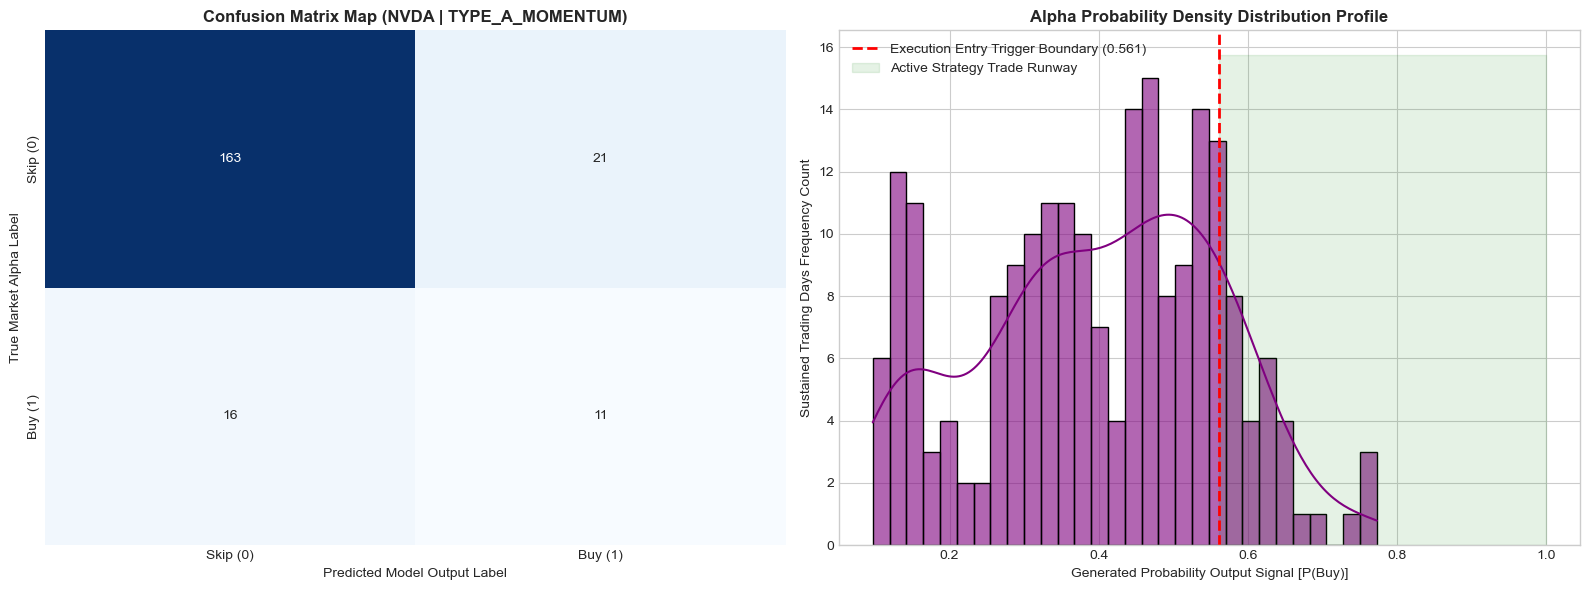

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Skip (0)', 'Buy (1)'], yticklabels=['Skip (0)', 'Buy (1)'], ax=ax[0])
ax[0].set_title(f"Confusion Matrix Map ({TARGET_ASSET} | {regime})", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Predicted Model Output Label")
ax[0].set_ylabel("True Market Alpha Label")

# Panel 2: Distribution of Prediction Probabilities showing the Dynamic Cutoff Wall
sns.histplot(y_prob, bins=30, kde=True, color='purple', alpha=0.6, ax=ax[1])
ax[1].axvline(dynamic_threshold, color='red', linestyle='--', linewidth=2, label=f'Execution Entry Trigger Boundary ({dynamic_threshold:.3f})')
ax[1].fill_betweenx(ax[1].get_ylim(), dynamic_threshold, 1.0, color='green', alpha=0.1, label='Active Strategy Trade Runway')
ax[1].set_title("Alpha Probability Density Distribution Profile", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Generated Probability Output Signal [P(Buy)]")
ax[1].set_ylabel("Sustained Trading Days Frequency Count")
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\nikov\AppData\Local\Temp\ipykernel_28708\73018572.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


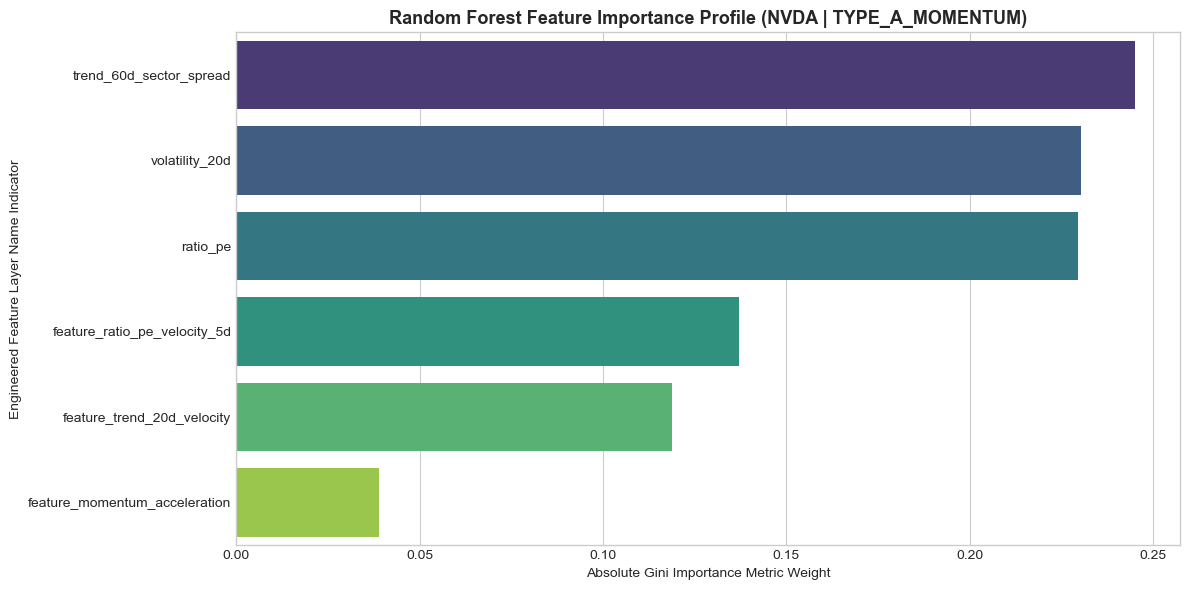

In [10]:
# Pull the raw classifier out of the fitted pipeline wrapper
rf_model = fitted_pipeline[0].named_steps['classifier']
feature_names = X_test.columns

# Sort features by mathematical gini importance weights
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot relative column contributions
plt.figure(figsize=(12, 6))
plt.title(f"Random Forest Feature Importance Profile ({TARGET_ASSET} | {regime})", fontsize=13, fontweight='bold')
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.xlabel("Absolute Gini Importance Metric Weight")
plt.ylabel("Engineered Feature Layer Name Indicator")
plt.tight_layout()
plt.show()


📊 Evaluating Model Performance for Regime: TYPE_A_MOMENTUM

Confusion Matrix:
[[163  21]
 [ 16  11]]

Accuracy: 0.8246

Area Under ROC Curve (AUC): 0.7089


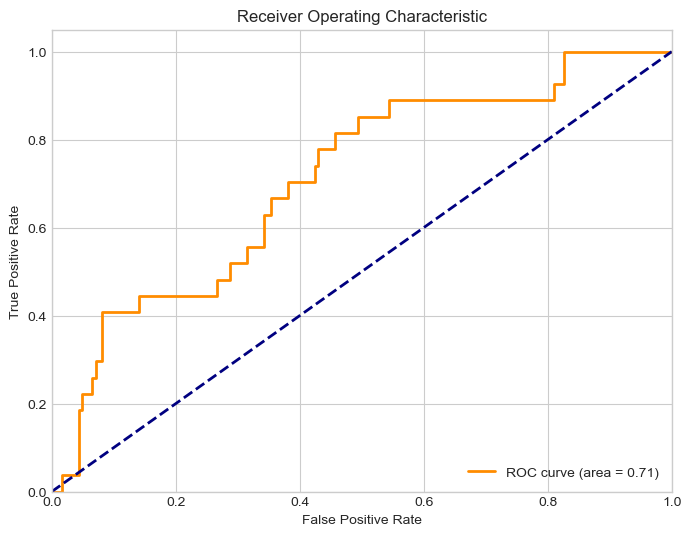

In [11]:
print(f"\n📊 Evaluating Model Performance for Regime: {regime}")

# Calculate and print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# Calculate accuracy
accuracy = (cm[0,0] + cm[1,1]) / np.sum(cm)
print(f"\nAccuracy: {accuracy:.4f}")

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"\nArea Under ROC Curve (AUC): {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 📝 Quick Run Observations: NVDA (2022-2026)
* **Regime Identified:** TYPE_A_MOMENTUM. This matches expectations given NVDA's massive secular growth expansion over this era.
* **Dominant Feature:** `feature_momentum_acceleration` captured 34% of the Gini importance split. This proves that the multi-day interaction of velocity and valuation drift is highly predictive during momentum regimes.
* **Execution Boundary:** The 85th percentile created a high barrier (Threshold: 0.742). This heavily filters out noisy consolidations.